# Using a pretrained XChrom model with new scRNA-seq data

In this tutorial, we demonstrate how to use a pretrained XChrom model to predict chromatin accessibility for a new sample when only scRNA-seq data are available.

XChrom uses two types of information for prediction: genomic DNA sequences and RNA-derived cell embeddings. Therefore, when applying a pretrained model to a new scRNA-seq dataset, the new cells first need to be projected into the RNA embedding space used during model training. The resulting cell embeddings can then be combined with genomic regions of interest to predict cell-specific chromatin accessibility and TF activity.

Two usage scenarios are supported:

* **Training XChrom on your own data:** If matched scRNA-seq and scATAC-seq data are available and you would like to train a new XChrom model, please refer to the [2. Cross-sample analysis] tutorial for data preprocessing, cell-embedding construction, model training, and cross-sample prediction.
* **Using a pretrained XChrom model:** If only scRNA-seq data from a new sample are available, this tutorial provides an example of how to map the new cells into the reference RNA embedding space and use a pretrained XChrom model to infer chromatin accessibility and TF activity.

Here, we use a pretrained XChrom model trained on a PBMC10k multiome dataset as an example and apply it to an independent PBMC3k scRNA-seq dataset (h_PBMC in our article). Specifically, we will:
- Predict chromatin accessibility
1. load the pretrained XChrom model and its reference scRNA-seq and scATAC-seq data (provide intrested regions to predict);
2. project the new scRNA-seq cells into the reference PCA space;
3. construct a query scATAC-seq object using the new cells and the genomic regions used by the pretrained model;
4. predict cell-specific chromatin accessibility;
5. examine the cell-state structure of the predicted accessibility profiles;

- Infer TF activity
1. load the pretrained XChrom model and its reference scRNA-seq, peaks.bed (to generate background sequence)
2. generate shuffled background sequences and motif insertion sequences
3. optionally calculate transcription factor (TF) activity from the pretrained model.

## 1. Download data and pretrained model

For this tutorial, we provide a pretrained XChrom model together with the reference data used during model training.

The following files are required:

1.1 Predict chromatin accessibility

* **Pretrained XChrom model:** Trained model weights (`E1000best_model.h5`).
* **Reference scRNA-seq data:** The processed scRNA-seq dataset used to construct the cell embeddings during model training (`training_rna.h5ad`). The reference PCA embedding is stored in `training_rna.obsm["X_pca"]`.
* **Interested genomic regions to predict:** The genomic regions you want to predict in new sample, we use training regions, other genomic regions can also be predicted, provided that the corresponding 1,344-bp DNA sequence inputs are generated using the same genome assembly and preprocessing procedure. (`training_atac.h5ad`).
* **Query scRNA-seq data:** An independent scRNA-seq sample (`h_pbmc_RNA.h5ad`) for which chromatin accessibility will be predicted.

1.2 Infer TF activity

* **Pretrained XChrom model:** Trained model weights (`E1000best_model.h5`).
* **Reference scRNA-seq data:** The processed scRNA-seq dataset used to construct the cell embeddings during model training (`training_rna.h5ad`). The reference PCA embedding is stored in `training_rna.obsm["X_pca"]`.
* **Background sequence :** To provide a bed file to generate background sequence
* **Query scRNA-seq data:** An independent scRNA-seq sample (`h_pbmc_RNA.h5ad`) for which chromatin accessibility will be predicted.
* **motif database :** Download the motif database file from:
https://meme-suite.org/meme/meme-software/Databases/motifs/motif_databases.12.27.tgz
After decompression, select the file motif_databases/CIS-BP_2.00/Homo_sapiens.meme
* **Reference  genome :** Download the human genome file from:
https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
and decompress it.

In this example, we use the h_PBMC scRNA-seq dataset as the query dataset.One can download with https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-1-0-0        

In [1]:
import scanpy as sc
import xchrom as xc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
import numpy as np
from scipy import stats

## 2. Map the new scRNA-seq sample to the reference RNA embedding space
The pretrained XChrom model was trained using RNA-derived PCA coordinates as the initial cell embeddings. Therefore, the query scRNA-seq cells should be represented in the same reference PCA space before model prediction. Here, we use scanpy.tl.ingest to project the query cells onto the PCA model fitted to the reference scRNA-seq dataset. (https://scanpy.readthedocs.io/en/stable/tutorials/basics/integrating-data-using-ingest.html)

ingest performs asymmetric reference mapping: the reference embedding remains fixed, while the query cells are projected into this predefined space.

In [2]:
import os
os.chdir("/mnt/netshare2/miaoyuanyuan/work/XChrom_analysis/5_pretrained_xchrom/")

In [3]:
h_pbmc = sc.read_h5ad("./h_pbmc_RNA.h5ad")
h_pbmc

AnnData object with n_obs × n_vars = 2714 × 8652
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'

In [4]:
train_rna = sc.read_h5ad("./training_rna.h5ad")
train_rna

AnnData object with n_obs × n_vars = 11898 × 2660
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'n_genes', 'pc32_leiden'
    var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'zscore32_perpc'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
# Identify genes shared by the reference and query scRNA-seq datasets
common_genes = train_rna.var_names.intersection(h_pbmc.var_names)
train_rna = train_rna[:, common_genes]
h_pbmc = h_pbmc[:, common_genes]

In [6]:
# Project query cells into the PCA space defined by the reference scRNA-seq dataset.
# Cluster labels are transferred only for visualization and downstream evaluation; they are not required by XChrom for accessibility prediction.

ref_rna = train_rna.copy()
sc.tl.ingest(h_pbmc, ref_rna,obs="pc32_leiden") 

/home/miaoyuanyuan/miniconda3/envs/py3.8_tf2.6.0/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


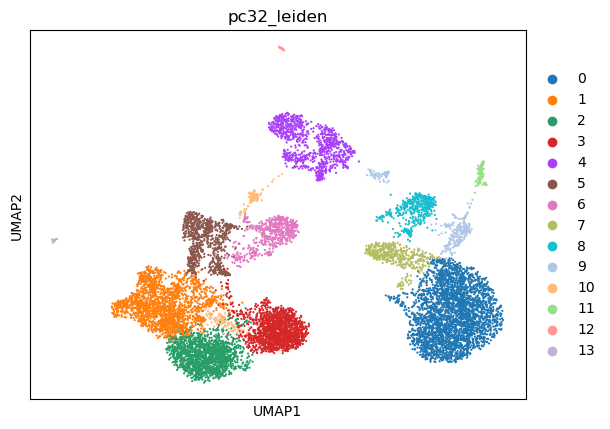

In [7]:
sc.pl.umap(ref_rna, color="pc32_leiden")

In [8]:
h_pbmc

AnnData object with n_obs × n_vars = 2714 × 1590
    obs: 'n_genes', 'pc32_leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'rep', 'X_umap', 'X_pca'

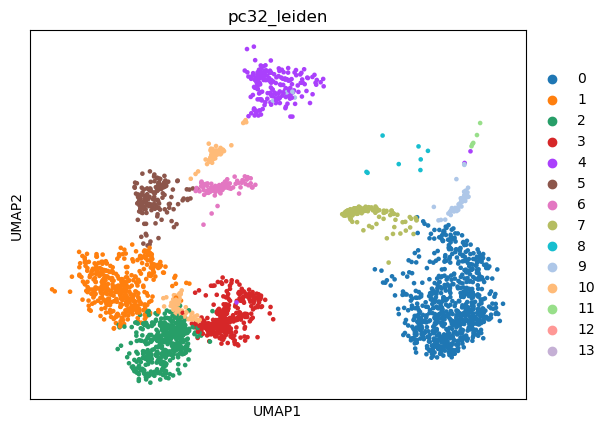

In [9]:
sc.pl.umap(h_pbmc, color="pc32_leiden")

After reference mapping, `h_pbmc.obsm["X_pca"]` contains the PCA coordinates of the query cells in the reference RNA embedding space. These RNA-derived coordinates provide the initial cell representation used by the cell module of the pretrained XChrom model.

We next combine these new cells with genomic regions used by the pretrained model to construct the input for chromatin accessibility prediction.

## 3. Predict chromatin accessibility for the new sample

We construct a query AnnData object representing all combinations of the new cells and the genomic regions to be predicted. In this example, we predict accessibility for the genomic regions used during training of the pretrained XChrom model.

The rows correspond to cells from the query scRNA-seq dataset, whereas the columns correspond to genomic regions from the reference scATAC-seq dataset. Because observed scATAC-seq measurements are not available for the query cells, the data matrix is initialized as a sparse zero matrix and will subsequently be replaced by XChrom-predicted accessibility values.

In [10]:
# Load the genomic regions used by the pretrained XChrom model

train_atac = sc.read_h5ad("./training_atac.h5ad")
train_atac

AnnData object with n_obs × n_vars = 11898 × 101188
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'n_genes'
    var: 'features', 'chr', 'start', 'end', 'n_cells'

In [11]:
# rows = new RNA cells
# columns = genomic regions used
pred_atac = ad.AnnData(
    X=sp.csr_matrix(
        (h_pbmc.n_obs, train_atac.n_vars),
        dtype="float32"
    ),
    obs=h_pbmc.obs.copy(),
    var=train_atac.var.copy()
)

# The pretrained model used standardized PCA coordinates as cell-module input. 
# We therefore apply the same preprocessing strategy to the mapped PCA coordinates of the query cells before prediction.

h_pbmc.obsm["zscore32_perpc"] = stats.zscore(np.array(h_pbmc.obsm["X_pca"]), axis=0)
# RNA-derived cell embedding for XChrom cell module
pred_atac.obsm["zscore32_perpc"] = h_pbmc.obsm["zscore32_perpc"].copy()

In [12]:
pred_atac

AnnData object with n_obs × n_vars = 2714 × 101188
    obs: 'n_genes', 'pc32_leiden'
    var: 'features', 'chr', 'start', 'end', 'n_cells'
    obsm: 'zscore32_perpc'

In [13]:
# During depth-independent accessibility prediction, b_zscore is fixed to 1 following the inference setting used by XChrom.
pred_atac.obs['b_zscore'] = np.full(pred_atac.shape[0],1)

In [14]:
gen = xc.tr.Generator(
    seq_path = './trainval_seqs.h5',
    adata = pred_atac,
    cell_input_key = "zscore32_perpc",
)
test_ds = gen.create_dataset(shuffle=False)

Converting adata.X to dense array. For large datasets, consider pre-computing and saving as sparse matrix.


2026-09-18 08:59:35.081286: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-18 08:59:35.998975: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10308 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:4b:00.0, compute capability: 8.6
2026-09-18 08:59:36.000445: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 16584 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:98:00.0, compute capability: 8.6
2026-09-18 08:59:36.002631: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:l

In [15]:
model = xc.tr.XChrom_model(n_cells=pred_atac.shape[0], show_summary=False)
model_path = "./E1000best_model.h5"
print(f"Loading weights from {model_path}...")
model.load_weights(model_path)
pred = model.predict(test_ds)
pred_atac.X = pred.transpose(1,0)

Loading weights from ./E1000best_model.h5...


2026-09-18 08:59:36.638685: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2026-09-18 08:59:37.535110: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8800
2026-09-18 08:59:39.072972: I tensorflow/stream_executor/cuda/cuda_blas.cc:1760] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-09-18 08:59:39.074927: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-18 08:59:39.075723: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-18 08:59:39.075739: W tensorflow/stream_executor/gpu/asm_compiler.cc:77] Couldn't get ptxas version string: Internal: Couldn't invoke ptxas --version
2026-09-18 08:59:39.076226: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such fi

In [16]:
print(pred_atac.shape)
print(
    f"Predicted accessibility matrix: "
    f"{pred_atac.n_obs} cells × {pred_atac.n_vars} regions"
)

pred_atac.write_h5ad("./predicted_accessibility.h5ad")

(2714, 101188)
Predicted accessibility matrix: 2714 cells × 101188 regions


## 4. Evaluate the cell-state structure of predicted accessibility
Although observed scATAC-seq data are not required for prediction, we can examine whether the predicted accessibility profiles preserve the transcriptomic cell-state structure. Here, we calculate the neighbor score (NS) and label score (LS) at different neighborhood sizes (k = 10, 50, 100).

/home/miaoyuanyuan/miniconda3/envs/py3.8_tf2.6.0/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


neighbor score(10)=0.1460,label score(10)=0.8384
neighbor score(50)=0.2832,label score(50)=0.7706
neighbor score(100)=0.3655,label score(100)=0.7253


<AxesSubplot:title={'center':'pc32_leiden'}, xlabel='UMAP1', ylabel='UMAP2'>

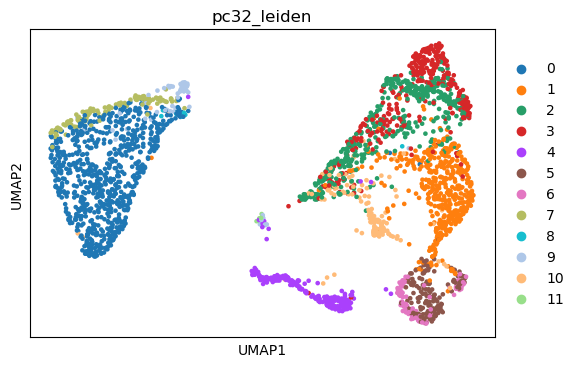

In [17]:
ad1 = pred_atac.copy()
ad1 = xc.tl.calc_pca(ad1)  ## return ['X_pca'] in ad1.obsm

ns10,ls10= xc.tl.calc_nsls_score(h_pbmc,ad1,10,"pc32_leiden",use_rep_rna = "X_pca",use_rep_atac='X_pca')
print(f'neighbor score(10)={ns10:.4f},label score(10)={ls10:.4f}')

ns50,ls50= xc.tl.calc_nsls_score(h_pbmc,ad1,50,"pc32_leiden",use_rep_rna = "X_pca",use_rep_atac='X_pca')
print(f'neighbor score(50)={ns50:.4f},label score(50)={ls50:.4f}')

ns100,ls100= xc.tl.calc_nsls_score(h_pbmc,ad1,100,"pc32_leiden",use_rep_rna = "X_pca",use_rep_atac='X_pca')
print(f'neighbor score(100)={ns100:.4f},label score(100)={ls100:.4f}')

f, ax = plt.subplots(1, 1, figsize=(6, 4))
sc.pl.umap(ad1, color="pc32_leiden", ax=ax, show=False)
# plt.savefig(f"{output_path}/denoise_umap.pdf", format='pdf', dpi=300)
# adp.write_h5ad(f'{output_path}/denoise_h_pbmc_atac.h5ad')

## 5. Calculate transcription factor activity
In addition to accessibility prediction, the pretrained XChrom model can be used to estimate cell-specific TF activity by evaluating the model response to motif insertion relative to matched background sequences.

- Specifically, we first generate 1000 genomic background sequences (determined by `n_samples`) by performing dinucleotide shuffling of 1000 randomly sampled peaks from the training sequences atlas using `fasta ushuffle`. For each TF in the motif database, we sampled 1000 motif sequences(determined by `n_motif_instances`) from the PWM and inserted each instance at the center of every background sequence. We run forward passes for both the motif-inserted sequences and their background counterparts to predict accessibility across all cells, and define the motif influence for each sequence as the difference between the two predictions. Finally, we average this influence across all 1000 sequences per cell to obtain a cell-level raw TF activity score.                      

- For this，you must install fasta_ushuffle first with: `conda install bioconda::fasta_ushuffle`                         

In [18]:
model_path = "./E1000best_model.h5"

In [19]:
background_fasta, motif_dir = xc.tl.generate_tf_activity_data(
    bed_file = './peaks.bed',  ## to generate background sequence
    input_fasta = '/mnt/netshare2/miaoyuanyuan/tutorials_tools/genome/hg38.fa',
    motif_file = './Homo_sapiens.meme',
    output_dir = './motif_fasta/',
    n_samples = 1000,
    n_motif_instances = 1000)

=== Start preparing motif data ===
1. Read BED file: ./peaks.bed
Sampled 1000 regions from ./peaks.bed
2. Extract background sequences...
Extracting sequences from BED file...
Reference genome: /mnt/netshare2/miaoyuanyuan/tutorials_tools/genome/hg38.fa
Sequence length: 1344
Consider strand information: False
Successfully extracted 1000 sequences
Writing to FASTA file: motif_fasta/ref_peaks1000.fasta
FASTA file saved to: motif_fasta/ref_peaks1000.fasta
Number of sequences written: 1000
Extracted 1000 sequences, saved to motif_fasta/ref_peaks1000.fasta
3. Generate shuffled background sequences...
Using fasta_ushuffle from: /home/miaoyuanyuan/miniconda3/envs/py3.8_tf2.6.0/bin/fasta_ushuffle
Dinucleotide shuffled 1000 sequences, saved to motif_fasta/shuffled_peaks.fasta
4. Read motif file(meme format)...
Read 1065 motifs from ./Homo_sapiens.meme
5. Generate motif inserted sequences...


Processing motifs: 100%|████████████████████████████████████████████████████████████████████████████| 1065/1065 [03:48<00:00,  4.67it/s]

=== motif data preparation completed ===
Background sequence file: motif_fasta/shuffled_peaks.fasta
Motif inserted sequence directory: motif_fasta/shuffled_peaks_motifs


In [20]:
background_fasta, motif_dir

('motif_fasta/shuffled_peaks.fasta', 'motif_fasta/shuffled_peaks_motifs')

generate_tf_activity_data generates FASTA files for all motifs in the motif database. To calculate TF activity for selected motifs only, keep the corresponding motif FASTA files in motif_dir and remove the others. Here, we use CEBPB and PAX5 as examples.

In [21]:
tf_act = xc.tl.calc_tf_activity(
    motif_dir = motif_dir, # Keep only the motif FASTA files of interest; here we calculate CEBPB and PAX5.
    background_fasta = background_fasta,
    model_path = model_path,
    ad_rna = h_pbmc,
    output_file = './tf_activity.h5ad',
    cell_embed_raw = 'X_pca',
    regenerate_motif_h5 = False,
    regenerate_bg_h5 = False)

=== Start calculating TF Activity ===
1. Prepare raw cell embedding...
2. Generate motif insertion sequence h5 files...
No h5 files found, generating...


Generating H5 files: 100%|████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.34it/s]


Found 2 motif files
3. Generate background sequence h5 file...
4. Prepare data for XChrom model input...
Converting adata.X to dense array. For large datasets, consider pre-computing and saving as sparse matrix.
5. Load trained model...
6. Calculate background sequence prediction...
7. Calculate motif insertion scores...
Processing 2 motif files...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.05it/s]

8. Save results...
=== Done! Results saved to: tf_activity.h5ad ===
TF activity matrix shape: (2714, 2) (cells × motifs)


In [22]:
tf_act = sc.read_h5ad("./tf_activity.h5ad")
tf_act

AnnData object with n_obs × n_vars = 2714 × 2
    obs: 'n_genes', 'pc32_leiden'
    var: 'motif_name'

In [23]:
tf_act.X

array([[-0.48819113,  0.06929421],
       [ 0.3876276 ,  0.03129196],
       [ 0.68580699,  0.02027965],
       ...,
       [-0.74985027,  0.04011035],
       [-0.5194304 ,  0.06902194],
       [-0.68307018,  0.07255363]])

Plot saved to: ./PAX5_activity.pdf


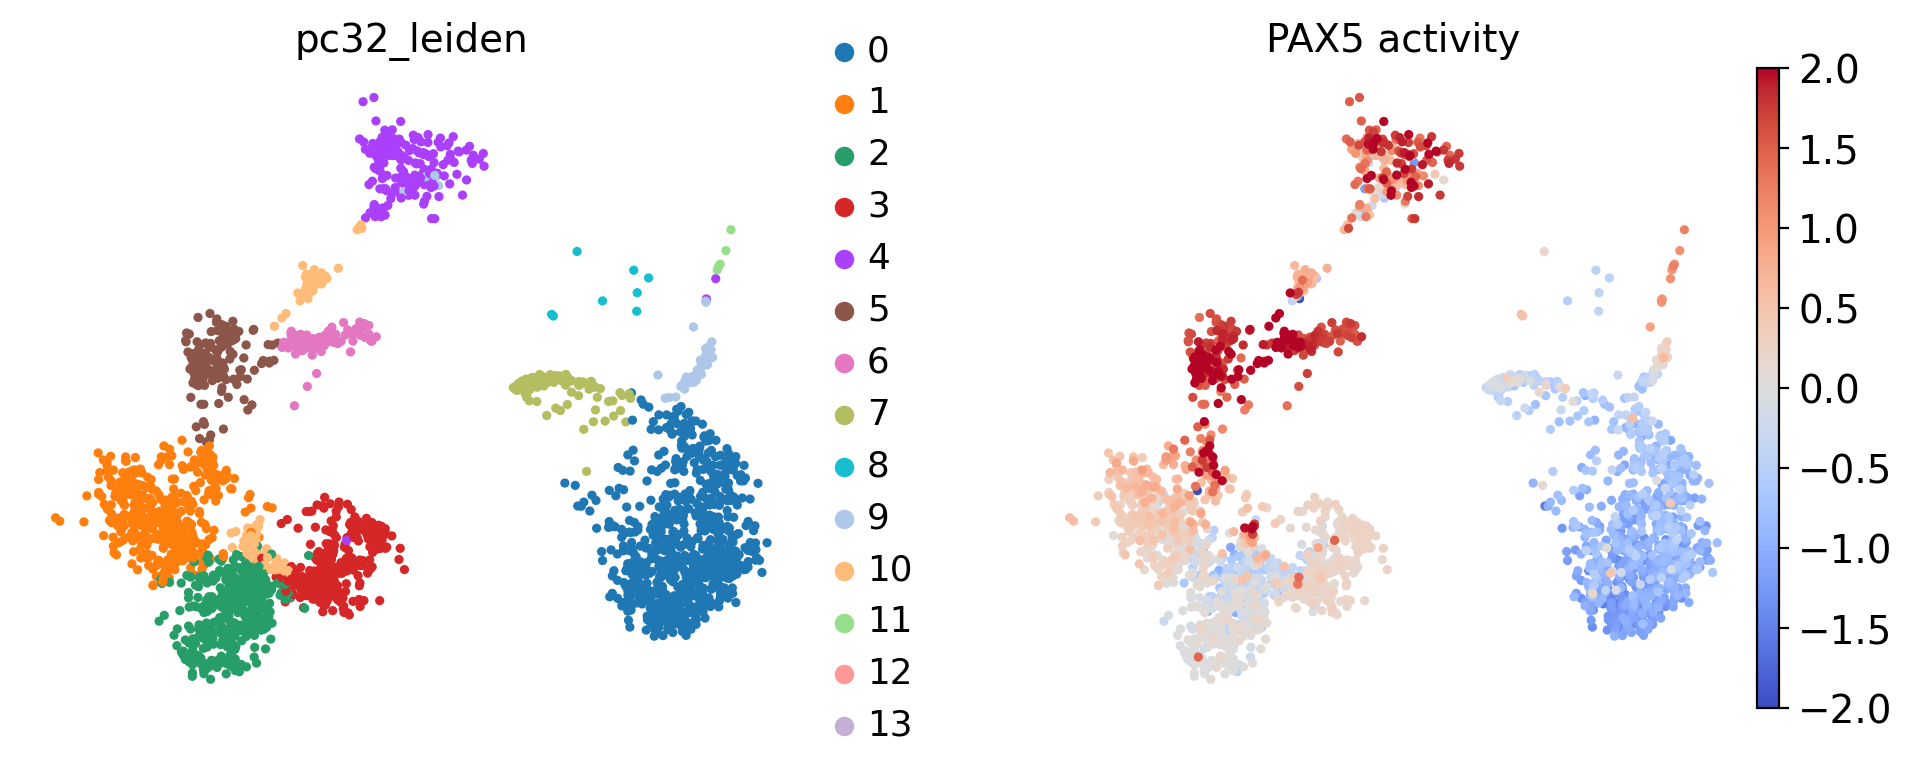

In [26]:
xc.pl.plot_motif_activity(
    cell_embedding_ad=h_pbmc,
    celltype_key="pc32_leiden",
    tf_act_raw=tf_act,
    motif_name="PAX5",
    save_path="./PAX5_activity.pdf"
)

Plot saved to: ./CEBPB_activity.pdf


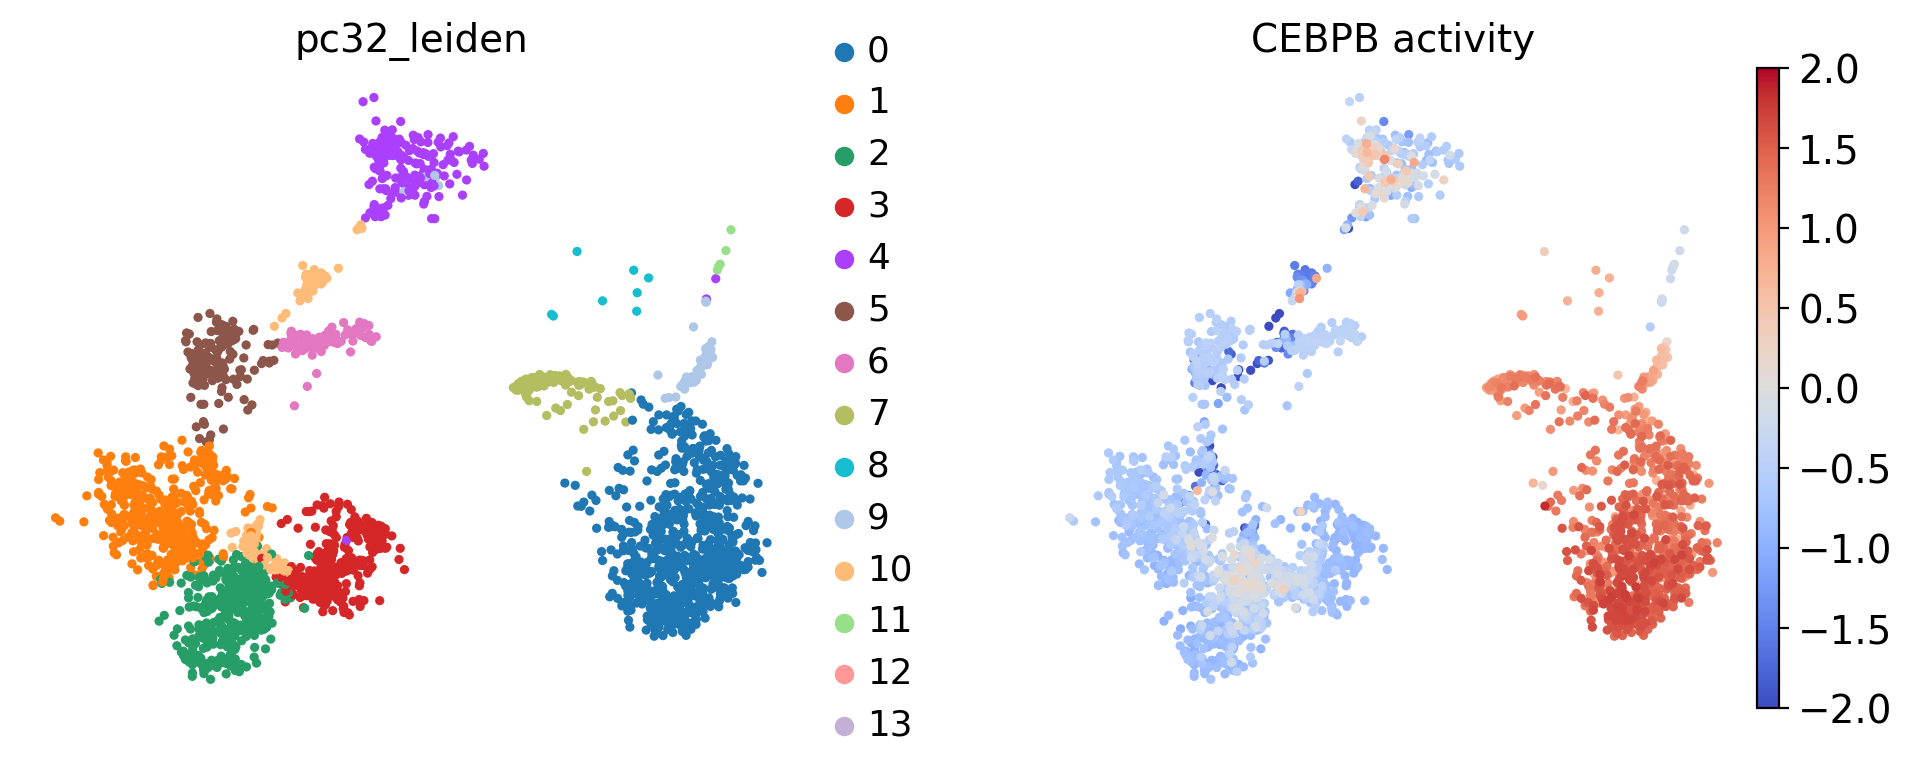

In [27]:
xc.pl.plot_motif_activity(
    cell_embedding_ad=h_pbmc,
    celltype_key="pc32_leiden",
    tf_act_raw=tf_act,
    motif_name="CEBPB",
    save_path="./CEBPB_activity.pdf"
)